# oncoPrint: visualizing GBM Variants Dataset

In [1]:
import os,sys
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pylab as plt
import pickle
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi']=300
plt.rcParams['font.family']='sans serif'
plt.rcParams['font.sans-serif']='Arial'
plt.rcParams['pdf.fonttype']=42
sys.path.append(os.path.expanduser("~/Projects/Github/PyComplexHeatmap/"))
from PyComplexHeatmap import *
from PyComplexHeatmap.utils import despine
use_pch_style() # or plt.style.use('default') to restore default style

In [2]:
# read
f=open("../data/data.pkl",'rb'); 
df_donor,df_oncoprint,df_ct_frac,df_dmr_state,df_loop_state,df_hic_state=pickle.load(f); 
f.close()

In [3]:
cols=['Mut','Loss','Gain']
oncoprint_colors = ['#D55E00','#CC79A7','#0072B2']
print(cols,oncoprint_colors)

['Mut', 'Loss', 'Gain'] ['#D55E00', '#CC79A7', '#0072B2']


In [4]:
row_vc=df_oncoprint.groupby('Gene').apply(lambda x:x.loc[:,cols].sum())
col_vc=df_oncoprint.groupby('SampleID').apply(lambda x:x.loc[:,cols].sum())
row_var_freq=df_oncoprint.assign(IsVar=(df_oncoprint.loc[:,cols].sum(axis=1)>0)).groupby('Gene').IsVar.sum() * 100 / df_oncoprint.SampleID.nunique()

top_annotation=HeatmapAnnotation(axis=1,orientation='up',
                                Col=anno_barplot(col_vc,colors=oncoprint_colors,legend=False,height=15,linewidth=0.1),
                                verbose=0, label_side='left', label_kws={'horizontalalignment': 'right','visible':False})

right_annotation = HeatmapAnnotation(axis=0,orientation='right',
                                Row=anno_barplot(row_vc,colors=oncoprint_colors,legend=False,height=15,linewidth=0.1),
                                label=anno_label(row_var_freq.apply(lambda x:str(round(x,1))+" %"),
                                                 height=1,relpos=(0,0.5)),
                                verbose=0, label_side='top',
                                label_kws={'horizontalalignment': 'left','rotation':45,'visible':False})

In [5]:
row_vc.head()

,Mut,Loss,Gain
Gene,,,
ARID1A,1,10,1
ARID1B,1,9,2
ATRX,9,4,1
CDKN2A/B,0,33,1
CDKN2A/B/C,0,6,1


In [6]:
col_vc.head()

,Mut,Loss,Gain
SampleID,,,
BT00009,2,8,2
BT0002,2,2,0
BT0003,4,5,0
BT0008,0,5,3
BT0010,1,4,0


In [10]:
# data2d = df_oncoprint.assign(
# 			VALUE=df_oncoprint.loc[:, cols].apply(lambda x: x.tolist(), axis=1)
# 		).pivot(index='Gene', columns='SampleID', values="VALUE")
# data2d

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 25.930555555555557 mm


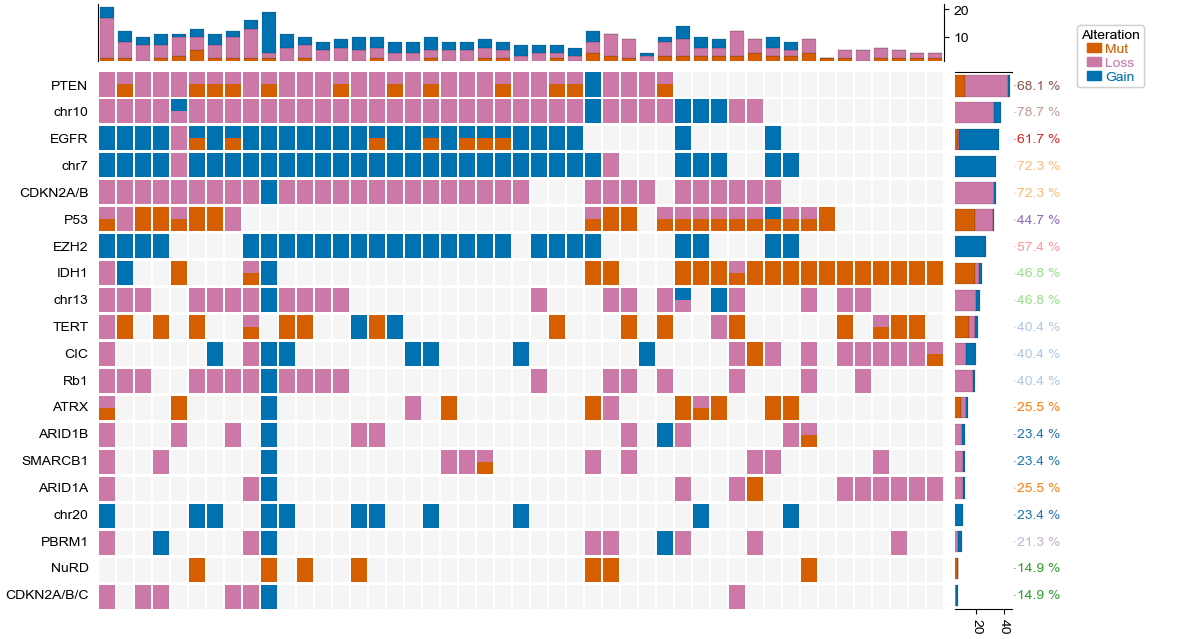

In [9]:
plt.figure(figsize=(12,8))
op=oncoPrintPlotter(data=df_oncoprint,y='Gene',x='SampleID',
                    values=cols,colors=oncoprint_colors,subplot_gap=3,label='Alteration',
                    top_annotation=top_annotation,right_annotation=right_annotation,
                   show_rownames=True,show_colnames=False,width=0.9)

# remove the grid
op.top_annotation.annotations[0].ax.grid(False)
#remove spines for top annotation and right annotation
despine(ax=op.top_annotation.annotations[0].ax,left=False, bottom=True, right=False, top=True)
despine(ax=op.right_annotation.annotations[0].ax,left=True, bottom=False, right=True, top=False)

plt.savefig("oncoPrint.pdf",bbox_inches='tight')
plt.show()